## Import libraries and setup

In [1]:
import os
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet


color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')


import warnings
warnings.filterwarnings('ignore')

In [2]:
%pwd

'f:\\Samith\\Github\\grid-forecast\\research'

In [3]:
os.chdir("../")

In [4]:
df = pd.read_parquet('artifacts/preprocessed/power_consumption_preprocessed.parquet')

In [5]:
TARGET = 'load_Actual Load'

In [6]:
df_sarima = df[TARGET].resample('h').mean()
df_sarima = df_sarima.interpolate(method="time", limit_direction="both")
print(df_sarima.shape)

(64763,)


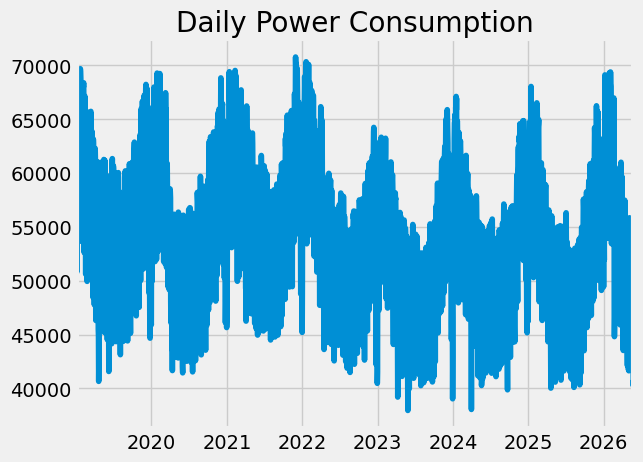

In [7]:
# Daily Power Consumption
df[TARGET].resample('D').mean().plot(title="Daily Power Consumption")

plt.show()

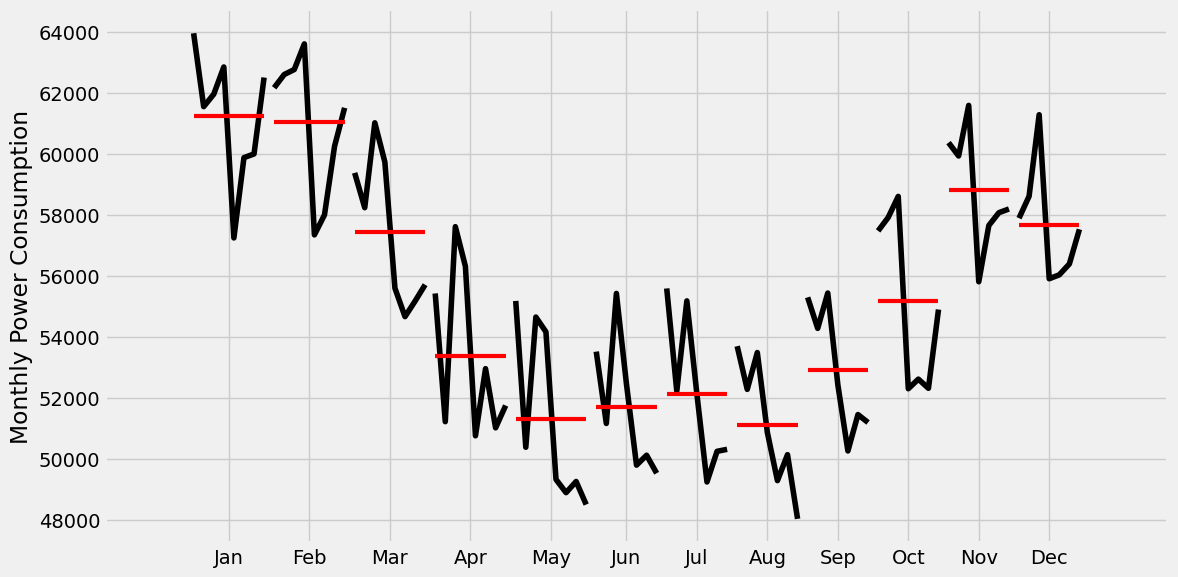

In [8]:
# Plotting the monthly seasonality

fig, ax = plt.subplots(figsize=(12, 6)) 
month_plot(df[TARGET].resample('ME').mean(),
           ylabel='Monthly Power Consumption', ax=ax)

plt.tight_layout()

plt.show()

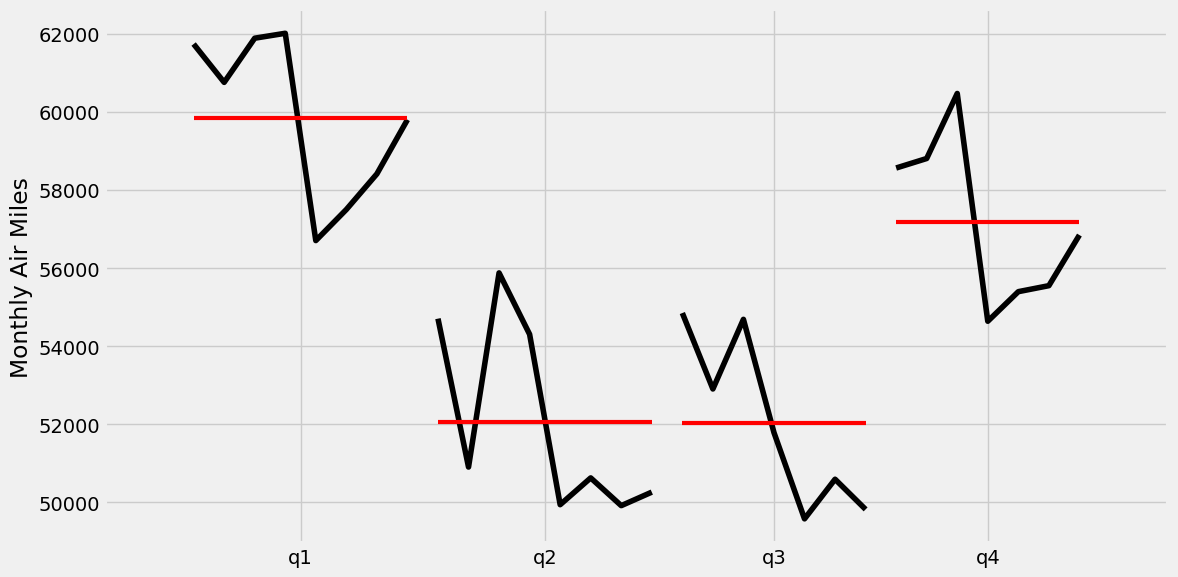

In [9]:
fig, ax = plt.subplots(figsize=(12, 6)) 
quarter_plot(df[TARGET].resample('QE').mean(),
           ylabel='Monthly Air Miles', ax=ax)
plt.tight_layout()
plt.show()

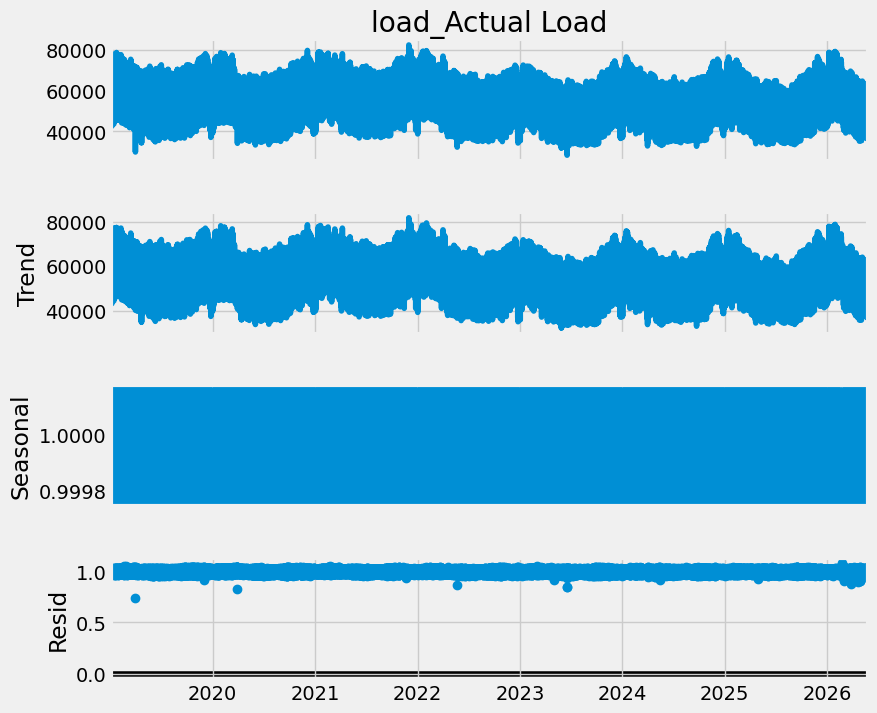

In [10]:
# Seasonal Decomposition PLots

decomposition = seasonal_decompose(df[TARGET], model='mul', period=12)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

ADF Statistic: -18.4424
p-value: 0.0000


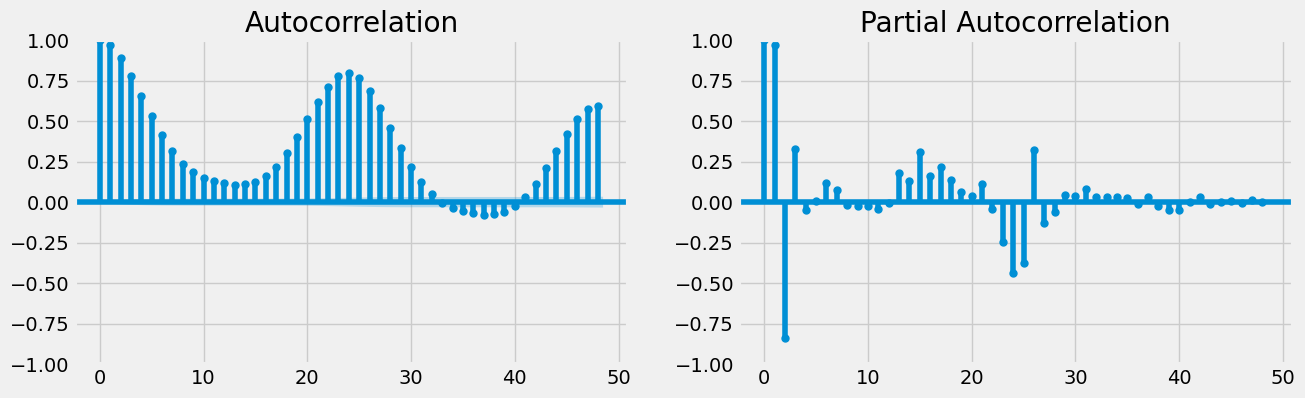

In [11]:
result = adfuller(df_sarima.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
# p-value < 0.05 means stationary — no differencing needed (d=0)
# p-value > 0.05 means non-stationary — need d=1

# Plot ACF and PACF to find p and q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_sarima.dropna(), lags=48, ax=axes[0])
plot_pacf(df_sarima.dropna(), lags=48, ax=axes[1])
plt.show()

In [12]:


# Train/test split 
train_sarima = df_sarima[(df_sarima.index > '2025-05-01') & (df_sarima.index < '2026-05-01')]
test_sarima  = df_sarima[df_sarima.index >= '2026-05-01']


order         = (2, 1, 1) 
seasonal_order = (1, 1, 1, 24)


predictions = []
actuals     = []

# Forecast one day at a time
forecast_horizon = 24  # 24 intervals = 1 day

# Refit every week
refit_frequency = 168  # 168 intervals = 1 week

history = train_sarima.copy()
fitted_model = None

print(f"Test size: {len(test_sarima)} hours")

for i in range(0, len(test_sarima), forecast_horizon):

    actual_window = test_sarima.iloc[i:i + forecast_horizon]

    if len(actual_window) == 0:
        break

    # Fit initially, then refit every week
    if fitted_model is None or i % refit_frequency == 0:
        print(f"Fitting model at step {i}/{len(test_sarima)}...")

        model = SARIMAX(
            history,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

    # Forecast next 96 intervals
    forecast = fitted_model.forecast(steps=len(actual_window))

    predictions.extend(forecast.values)
    actuals.extend(actual_window.values)

    # Update model state with actual observations before next forecast
    fitted_model = fitted_model.append(actual_window, refit=False)

    # Keep history updated for weekly refits
    history = pd.concat([history, actual_window])

# Evaluate
predictions = np.array(predictions)
actuals = np.array(actuals)

rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print("\nSARIMA Results:")
print(f"  RMSE: {rmse:.0f} MW")
print(f"  MAE:  {mae:.0f} MW")
print(f"  MAPE: {mape:.2f}%")

Test size: 600 hours
Fitting model at step 0/600...
Fitting model at step 168/600...
Fitting model at step 336/600...
Fitting model at step 504/600...

SARIMA Results:
  RMSE: 5162 MW
  MAE:  3744 MW
  MAPE: 7.88%


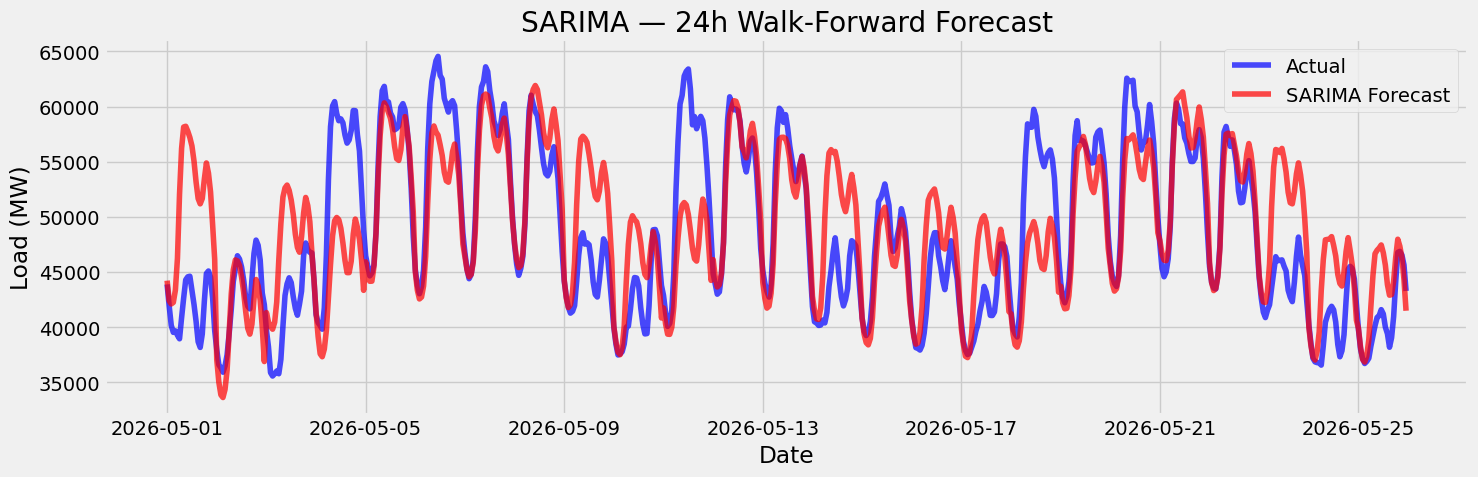

In [13]:

plt.figure(figsize=(15, 5))
plt.plot(test_sarima.index[:len(actuals)], actuals, 
         label='Actual', color='blue', alpha=0.7)
plt.plot(test_sarima.index[:len(predictions)], predictions, 
         label='SARIMA Forecast', color='red', alpha=0.7)
plt.title('SARIMA — 24h Walk-Forward Forecast')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.tight_layout()
plt.show()


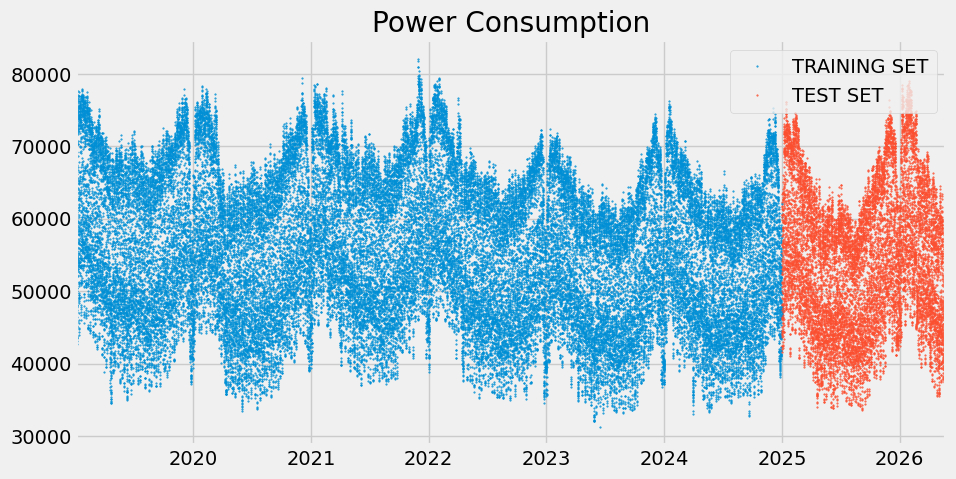

In [14]:
train= df_sarima[df_sarima.index < '2025-01-01']
test  = df_sarima[df_sarima.index >= '2025-01-01']



# Plot train and test so you can see where we have split
df_combined = pd.concat([
    train.rename('TRAINING SET'),
    test.rename('TEST SET')
], axis=1)

# Plot
df_combined.plot(figsize=(10, 5), title='Power Consumption', style='.', ms=1)
plt.show()

In [15]:
power_train_prophet = train.reset_index()
power_train_prophet.columns = ['ds', 'y']
power_train_prophet['ds'] = power_train_prophet['ds'].dt.tz_localize(None)

In [16]:
%%time
model = Prophet()
model.fit(power_train_prophet)

23:54:55 - cmdstanpy - INFO - Chain [1] start processing
23:56:14 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 12.9 s
Wall time: 1min 36s


In [17]:
power_test_prophet = test.reset_index()
power_test_prophet.columns = ['ds', 'y']
power_test_prophet['ds'] = power_test_prophet['ds'].dt.tz_localize(None)



power_test_fcst = model.predict(power_test_prophet)

In [18]:
power_test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01 00:00:00,53610.226221,42447.453314,51033.687264,53610.226221,53610.226221,-7033.045584,-7033.045584,-7033.045584,-8273.794844,...,3191.755679,3191.755679,3191.755679,-1951.006419,-1951.006419,-1951.006419,0.0,0.0,0.0,46577.180637
1,2025-01-01 01:00:00,53610.256131,39955.572909,49186.554566,53610.256131,53610.256131,-8875.553405,-8875.553405,-8875.553405,-10131.121931,...,3191.944076,3191.944076,3191.944076,-1936.375551,-1936.375551,-1936.375551,0.0,0.0,0.0,44734.702726
2,2025-01-01 02:00:00,53610.286041,38912.867733,47644.989263,53610.286041,53610.286041,-10174.365324,-10174.365324,-10174.365324,-11450.862462,...,3198.107308,3198.107308,3198.107308,-1921.610170,-1921.610170,-1921.610170,0.0,0.0,0.0,43435.920716
3,2025-01-01 03:00:00,53610.315951,38664.996829,47831.234133,53610.315951,53610.315951,-10404.593790,-10404.593790,-10404.593790,-11707.744581,...,3209.861520,3209.861520,3209.861520,-1906.710729,-1906.710729,-1906.710729,0.0,0.0,0.0,43205.722161
4,2025-01-01 04:00:00,53610.345861,40007.184493,49072.586500,53610.345861,53610.345861,-8984.683797,-8984.683797,-8984.683797,-10319.740942,...,3226.734825,3226.734825,3226.734825,-1891.677680,-1891.677680,-1891.677680,0.0,0.0,0.0,44625.662065


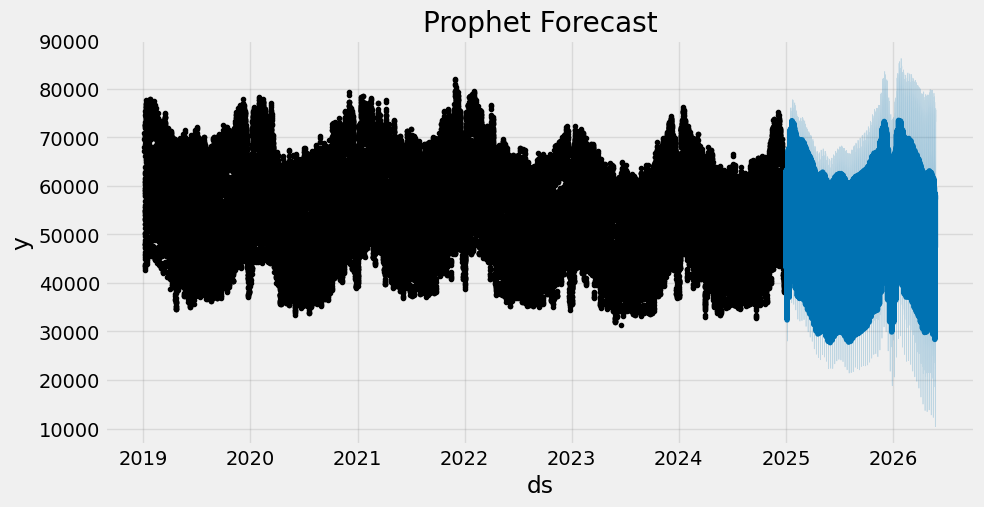

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(power_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

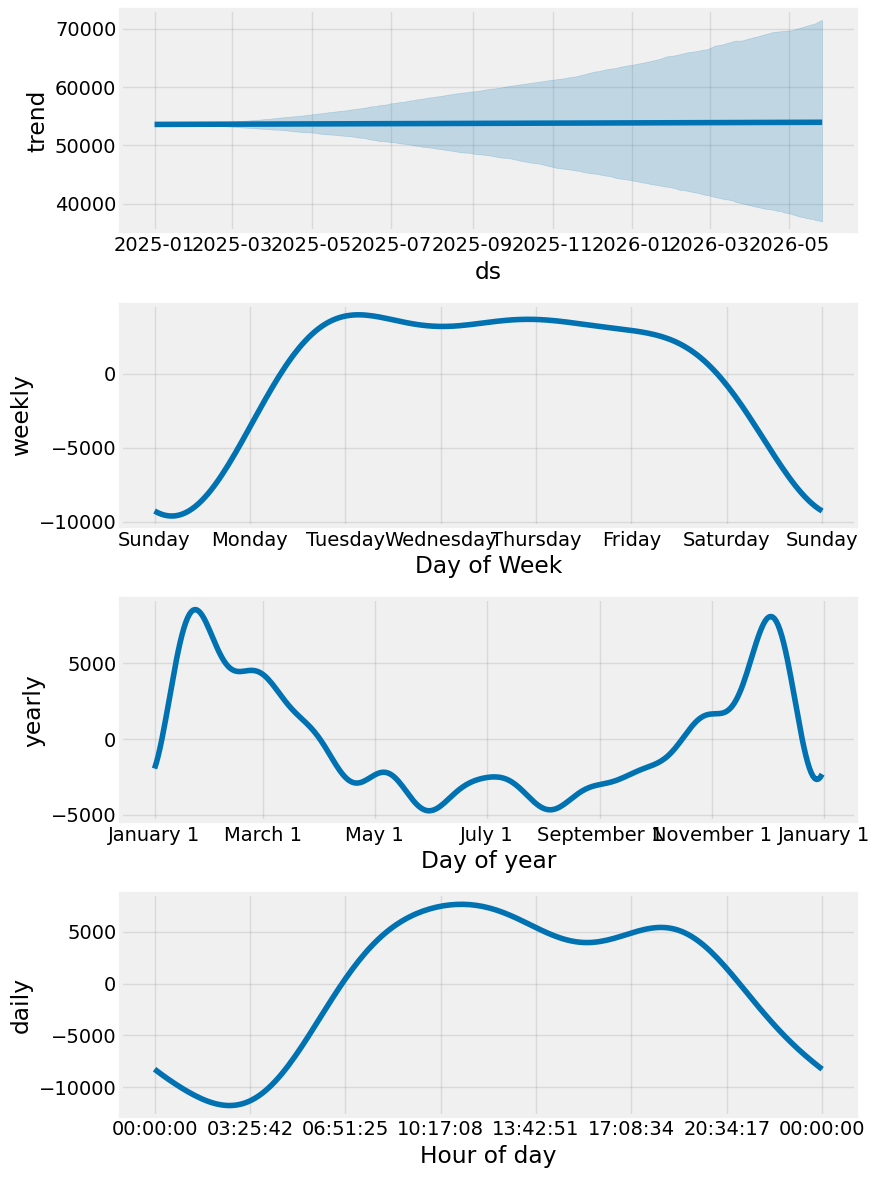

In [20]:
fig = model.plot_components(power_test_fcst)
plt.show()

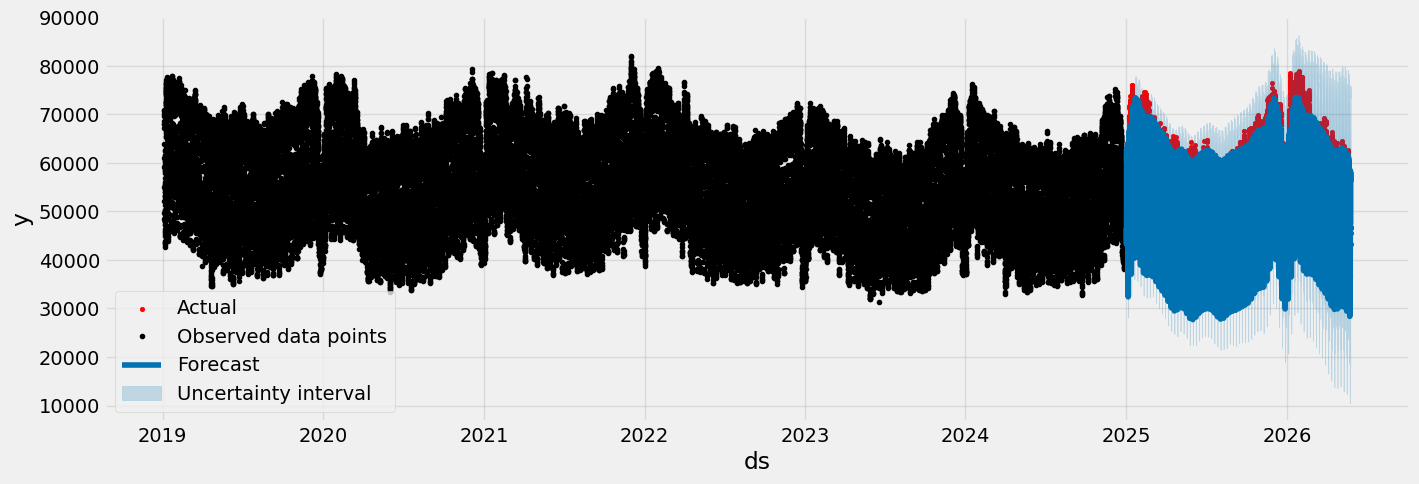

In [21]:
# Plot the forecast with the actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(test.index, test, color='r', label='Actual', s=10)

# Plot Prophet forecast
fig = model.plot(power_test_fcst, ax=ax)
plt.legend()
plt.show()

In [22]:
predictions_prophet = power_test_fcst['yhat'].values
actuals_prophet = test.values


rmse = np.sqrt(mean_squared_error(actuals_prophet, predictions_prophet))
mae = mean_absolute_error(actuals_prophet, predictions_prophet)
mape = np.mean(np.abs((actuals_prophet - predictions_prophet) / actuals_prophet)) * 100

print("\nProphet Results:")
print(f"  RMSE: {rmse:.0f} MW")
print(f"  MAE:  {mae:.0f} MW")
print(f"  MAPE: {mape:.2f}%")


Prophet Results:
  RMSE: 4002 MW
  MAE:  3012 MW
  MAPE: 5.78%


# Train - Test split 

In [23]:
df_model = df.copy()
df_model = df_model.sort_index()
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Avoid target leakage
drop_cols = [
    TARGET,
    "residual_load"
]

feature_cols = [c for c in df_model.columns if c not in drop_cols]

df_model = df_model.dropna(subset=[TARGET])
df_model = df_model.dropna(subset=feature_cols)

train = df_model.loc["2019-01-01":"2025-01-01"]
test = df_model.loc["2025-01-01":"2026-01-01"]

X_train = train[feature_cols]
y_train = train[TARGET]

X_test = test[feature_cols]
y_test = test[TARGET]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (209634, 92)
X_test: (35043, 92)


# Models

In [24]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true.values - y_pred) / y_true.values)) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Results")
    print(f"  RMSE: {rmse:.0f} MW")
    print(f"  MAE:  {mae:.0f} MW")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R2:   {r2:.4f}")

    return {
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "r2": r2
    }

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

ridge_metrics = evaluate_model("Ridge Regression", y_test, ridge_pred)


Ridge Regression Results
  RMSE: 385 MW
  MAE:  284 MW
  MAPE: 0.54%
  R2:   0.9983


In [26]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)

lgbm_metrics = evaluate_model("LightGBM", y_test, lgbm_pred)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.205418 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19569
[LightGBM] [Info] Number of data points in the train set: 209634, number of used features: 92
[LightGBM] [Info] Start training from score 55583.982165

LightGBM Results
  RMSE: 310 MW
  MAE:  231 MW
  MAPE: 0.44%
  R2:   0.9989


In [27]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_metrics = evaluate_model("XGBoost", y_test, xgb_pred)


XGBoost Results
  RMSE: 329 MW
  MAE:  243 MW
  MAPE: 0.46%
  R2:   0.9987


In [28]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

cat_metrics = evaluate_model("CatBoost", y_test, cat_pred)

0:	learn: 9568.3527909	total: 400ms	remaining: 6m 39s
100:	learn: 783.1788542	total: 11.7s	remaining: 1m 44s
200:	learn: 408.4531288	total: 20.4s	remaining: 1m 21s
300:	learn: 361.3245295	total: 29.2s	remaining: 1m 7s
400:	learn: 337.2283605	total: 38s	remaining: 56.8s
500:	learn: 322.5295513	total: 46.7s	remaining: 46.5s
600:	learn: 311.3483619	total: 55.5s	remaining: 36.8s
700:	learn: 303.1866768	total: 1m 4s	remaining: 27.4s
800:	learn: 296.4403644	total: 1m 12s	remaining: 18.1s
900:	learn: 290.6319913	total: 1m 22s	remaining: 9.02s
999:	learn: 285.9381314	total: 1m 30s	remaining: 0us

CatBoost Results
  RMSE: 349 MW
  MAE:  262 MW
  MAPE: 0.50%
  R2:   0.9986


In [29]:
results = pd.DataFrame([
    ridge_metrics,
    lgbm_metrics,
    xgb_metrics,
    cat_metrics
]).sort_values("rmse")

results

,model,rmse,mae,mape,r2
1,LightGBM,309.776046,230.518180,0.438096,0.998882
2,XGBoost,328.814041,242.519562,0.463078,0.998741
3,CatBoost,349.453381,261.533839,0.495601,0.998578
0,Ridge Regression,385.308448,283.761503,0.538041,0.998271
